In [9]:
import pandas as pd
def load_marketing_data(file_path , sheet_name = "marketing_campaign"):
    return pd.read_excel(file_path , sheet_name = sheet_name)
def classify_measurement_scale(column_name):
    nominal_features = {
        "ID",
        "Marital_Status",
        "Country",
        "AcceptedCmp1",
        "AcceptedCmp2",
        "AcceptedCmp3",
        "AcceptedCmp4",
        "AcceptedCmp5",
        "Complain",
        "Response"
    }
    ordinal_features = {
        "Education"
    }
    interval_features = {
        "Year_Birth",
        "Dt_Customer"
    }
    ratio_features = {
        "Income",
        "Kidhome",
        "Teenhome",
        "Recency",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "Z_CostContact",
        "Z_Revenue"
    }
    if column_name in nominal_features :
        return "Nominal"
    if column_name in ordinal_features :
        return "Ordinal"
    if column_name in interval_features :
        return "Interval"
    if column_name in ratio_features :
        return "Ratio"
    else :
        return "Unknown"
def identify_feature_types(data):
    feature_information = pd.DataFrame ({
        "Feature" : data.columns , 
        "Data Type" : data.dtypes.astype(str) ,
        "Measurement Scale" : [
            classify_measurement_scale(column)
            for column in data.columns
        ]
    })
    return feature_information
file_path = "Lab Session Data.xlsx"
marketing_data = load_marketing_data(file_path)
feature_information = identify_feature_types(marketing_data)
print("Marketing Campaign Dataset Features :")
print(feature_information)

Marketing Campaign Dataset Features :
                                 Feature Data Type Measurement Scale
ID                                    ID     int64           Nominal
Year_Birth                    Year_Birth     int64          Interval
Education                      Education    object           Ordinal
Marital_Status            Marital_Status    object           Nominal
Income                            Income   float64             Ratio
Kidhome                          Kidhome     int64             Ratio
Teenhome                        Teenhome     int64             Ratio
Dt_Customer                  Dt_Customer    object          Interval
Recency                          Recency     int64             Ratio
MntWines                        MntWines     int64             Ratio
MntFruits                      MntFruits     int64             Ratio
MntMeatProducts          MntMeatProducts     int64             Ratio
MntFishProducts          MntFishProducts     int64             Ra

In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
def label_encode_data(data, column_name):
    encoded_data = data.copy()
    label_encoder = LabelEncoder()
    encoded_data[column_name] = label_encoder.fit_transform(
        encoded_data[column_name]
    )
    return encoded_data
def one_hot_encode_data(data, column_name):
    encoded_data = pd.get_dummies(
        data,
        columns=[column_name],
        dtype=int
    )
    return encoded_data
data = pd.DataFrame({
    "Education": [
        "Basic",
        "Graduation",
        "Master",
        "PhD",
        "Graduation"
    ]
})
label_encoded_data = label_encode_data(data, "Education")
one_hot_encoded_data = one_hot_encode_data(data, "Education")
print("Original Data:")
print(data)
print("\nLabel Encoded Data:")
print(label_encoded_data)
print("\nOne-Hot Encoded Data:")
print(one_hot_encoded_data)

Original Data:
    Education
0       Basic
1  Graduation
2      Master
3         PhD
4  Graduation

Label Encoded Data:
   Education
0          0
1          1
2          2
3          3
4          1

One-Hot Encoded Data:
   Education_Basic  Education_Graduation  Education_Master  Education_PhD
0                1                     0                 0              0
1                0                     1                 0              0
2                0                     0                 1              0
3                0                     0                 0              1
4                0                     1                 0              0


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
def label_encode_data(data, column_name):
    encoded_data = data.copy()
    label_encoder = LabelEncoder()
    encoded_data[column_name] = label_encoder.fit_transform(
        encoded_data[column_name]
    )
    return encoded_data
def one_hot_encode_data(data, column_name):
    encoded_data = pd.get_dummies(
        data,
        columns=[column_name],
        dtype=int
    )
    return encoded_data
def convert_categorical_features(data):
    encoded_data = label_encode_data(
        data,
        "Education"
    )
    encoded_data = one_hot_encode_data(
        encoded_data,
        "Marital_Status"
    )
    return encoded_data
def study_feature_dimensionality(original_data, encoded_data):
    original_dimensions = original_data.shape[1]
    encoded_dimensions = encoded_data.shape[1]
    dimensionality_change = encoded_dimensions - original_dimensions
    return (
        original_dimensions,
        encoded_dimensions,
        dimensionality_change
    )
file_path = r"C:\Users\jaswa\Downloads\Lab Session Data.xlsx"
marketing_data = pd.read_excel(
    file_path,
    sheet_name="marketing_campaign"
)
encoded_marketing_data = convert_categorical_features(
    marketing_data
)
(
    original_dimensions,
    encoded_dimensions,
    dimensionality_change
) = study_feature_dimensionality(
    marketing_data,
    encoded_marketing_data
)
print("Original Dataset:")
print(marketing_data.head())
print("\nEncoded Dataset:")
print(encoded_marketing_data.head())
print("\nOriginal Feature Dimensionality:",
      original_dimensions)
print("Encoded Feature Dimensionality:",
      encoded_dimensions)
print("Change in Feature Dimensionality:",
      dimensionality_change)

Original Dataset:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

           Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0  2012-04-09 00:00:00       58       635  ...                  7   
1  2014-08-03 00:00:00       38        11  ...                  5   
2           21-08-2013       26       426  ...                  4   
3  2014-10-02 00:00:00       26        11  ...                  6   
4           19-01-2014       94       173  ...                  5   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  \
0             0        

In [4]:
import numpy as np
def calculate_minkowski_distance(point_a, point_b, order):
    point_a = np.array(point_a)
    point_b = np.array(point_b)
    if order <= 0:
        raise ValueError("Order must be a positive value.")
    distance = np.sum(np.abs(point_a - point_b) ** order) ** (1 / order)
    return distance
point_a = [1, 2, 3]
point_b = [4, 6, 8]
manhattan_distance = calculate_minkowski_distance(
    point_a,
    point_b,
    1
)
euclidean_distance = calculate_minkowski_distance(
    point_a,
    point_b,
    2
)
print("Manhattan Distance:", manhattan_distance)
print("Euclidean Distance:", euclidean_distance)

Manhattan Distance: 12.0
Euclidean Distance: 7.0710678118654755


Order Parameter and Minkowski Distance:
p = 1: Distance = 16781.0
p = 2: Distance = 12290.371231171172
p = 3: Distance = 11884.37455405266
p = 4: Distance = 11813.182056643884
p = 5: Distance = 11798.3594656484
p = 6: Distance = 11795.03214977206
p = 7: Distance = 11794.251319225397
p = 8: Distance = 11794.062464516399
p = 9: Distance = 11794.015771376238
p = 10: Distance = 11794.004031784574


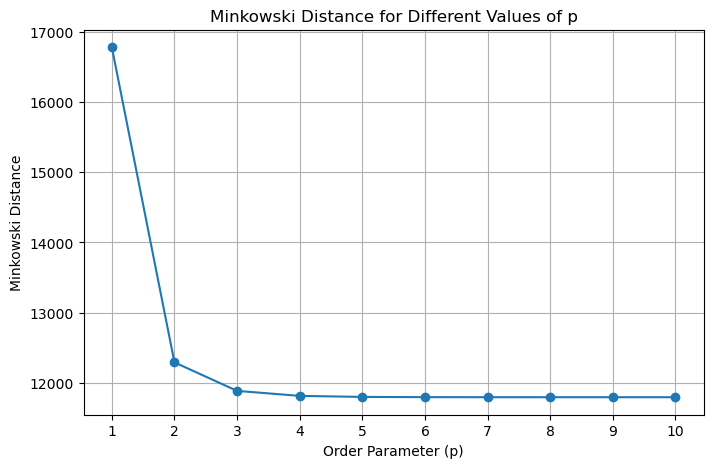

In [6]:
import numpy as np
import matplotlib.pyplot as plt
def calculate_minkowski_distance(point_a, point_b, order):
    point_a = np.array(point_a, dtype=float)
    point_b = np.array(point_b, dtype=float)
    if order <= 0:
        raise ValueError("Order must be a positive value.")
    distance = np.sum(
        np.abs(point_a - point_b) ** order
    ) ** (1 / order)
    return distance
def calculate_distances_for_orders(point_a, point_b, orders):
    distances = []
    for order in orders:
        distance = calculate_minkowski_distance(
            point_a,
            point_b,
            order
        )
        distances.append(distance)
    return distances
def plot_minkowski_distances(orders, distances):
    plt.figure(figsize=(8, 5))
    plt.plot(
        orders,
        distances,
        marker="o"
    )
    plt.xlabel("Order Parameter (p)")
    plt.ylabel("Minkowski Distance")
    plt.title("Minkowski Distance for Different Values of p")
    plt.xticks(orders)
    plt.grid(True)
    plt.show()
feature_vectors = encoded_marketing_data.select_dtypes(
    include=np.number
)
point_a = feature_vectors.iloc[0].values
point_b = feature_vectors.iloc[1].values
orders = range(1, 11)
distances = calculate_distances_for_orders(
    point_a,
    point_b,
    orders
)
print("Order Parameter and Minkowski Distance:")
for order, distance in zip(orders, distances):
    print(
        f"p = {order}: "
        f"Distance = {distance}"
    )
plot_minkowski_distances(
    orders,
    distances
)

In [8]:
import numpy as np
from scipy.spatial.distance import minkowski
def calculate_minkowski_distance(point_a, point_b, order):
    point_a = np.array(point_a, dtype=float)
    point_b = np.array(point_b, dtype=float)
    if order <= 0:
        raise ValueError("Order must be a positive value.")
    distance = np.sum(
        np.abs(point_a - point_b) ** order
    ) ** (1 / order)
    return distance
def compare_minkowski_distances(point_a, point_b, orders):
    comparison_results = []
    for order in orders:
        own_distance = calculate_minkowski_distance(
            point_a,
            point_b,
            order
        )
        scipy_distance = minkowski(
            point_a,
            point_b,
            p=order
        )
        comparison_results.append({
            "p": order,
            "Own Function": own_distance,
            "SciPy Function": scipy_distance,
            "Difference": abs(own_distance - scipy_distance)
        })
    return comparison_results
feature_vectors = encoded_marketing_data.select_dtypes(
    include=np.number
)
point_a = feature_vectors.iloc[0].values
point_b = feature_vectors.iloc[1].values
orders = range(1, 11)
comparison_results = compare_minkowski_distances(
    point_a,
    point_b,
    orders
)
print("Comparison of Minkowski Distance Values:")
for result in comparison_results:
    print(
        f"p = {result['p']}, "
        f"Own Function = {result['Own Function']}, "
        f"SciPy Function = {result['SciPy Function']}, "
        f"Difference = {result['Difference']}"
    )

Comparison of Minkowski Distance Values:
p = 1, Own Function = 16781.0, SciPy Function = 16781.0, Difference = 0.0
p = 2, Own Function = 12290.371231171172, SciPy Function = 12290.371231171172, Difference = 0.0
p = 3, Own Function = 11884.37455405266, SciPy Function = 11884.37455405266, Difference = 0.0
p = 4, Own Function = 11813.182056643884, SciPy Function = 11813.182056643884, Difference = 0.0
p = 5, Own Function = 11798.3594656484, SciPy Function = 11798.3594656484, Difference = 0.0
p = 6, Own Function = 11795.03214977206, SciPy Function = 11795.03214977206, Difference = 0.0
p = 7, Own Function = 11794.251319225397, SciPy Function = 11794.251319225397, Difference = 0.0
p = 8, Own Function = 11794.062464516399, SciPy Function = 11794.062464516399, Difference = 0.0
p = 9, Own Function = 11794.015771376238, SciPy Function = 11794.015771376238, Difference = 0.0
p = 10, Own Function = 11794.004031784574, SciPy Function = 11794.004031784574, Difference = 0.0


In [10]:
import numpy as np
def calculate_dot_product(vector_a, vector_b):
    if len(vector_a) != len(vector_b):
        raise ValueError("Both vectors must have the same dimension.")
    dot_product = 0
    for index in range(len(vector_a)):
        dot_product += vector_a[index] * vector_b[index]
    return dot_product
def calculate_euclidean_norm(vector):
    sum_of_squares = 0
    for value in vector:
        sum_of_squares += value ** 2
    return sum_of_squares ** 0.5
vector_a = np.array([1, 2, 3, 4])
vector_b = np.array([5, 6, 7, 8])
own_dot_product = calculate_dot_product(
    vector_a,
    vector_b
)
numpy_dot_product = np.dot(
    vector_a,
    vector_b
)
own_norm_a = calculate_euclidean_norm(vector_a)
numpy_norm_a = np.linalg.norm(vector_a)
own_norm_b = calculate_euclidean_norm(vector_b)
numpy_norm_b = np.linalg.norm(vector_b)
print("Dot Product:")
print("Own Function:", own_dot_product)
print("NumPy Function:", numpy_dot_product)
print("Difference:", abs(own_dot_product - numpy_dot_product))
print("\nEuclidean Norm of Vector A:")
print("Own Function:", own_norm_a)
print("NumPy Function:", numpy_norm_a)
print("Difference:", abs(own_norm_a - numpy_norm_a))
print("\nEuclidean Norm of Vector B:")
print("Own Function:", own_norm_b)
print("NumPy Function:", numpy_norm_b)
print("Difference:", abs(own_norm_b - numpy_norm_b))

Dot Product:
Own Function: 70
NumPy Function: 70
Difference: 0

Euclidean Norm of Vector A:
Own Function: 5.477225575051661
NumPy Function: 5.477225575051661
Difference: 0.0

Euclidean Norm of Vector B:
Own Function: 13.19090595827292
NumPy Function: 13.19090595827292
Difference: 0.0


In [12]:
import pandas as pd
import numpy as np
def calculate_mean(data):
    valid_data = data.dropna()
    return sum(valid_data) / len(valid_data)
def calculate_variance(data):
    valid_data = data.dropna()
    mean = calculate_mean(valid_data)
    squared_deviations = [
        (value - mean) ** 2
        for value in valid_data
    ]
    return sum(squared_deviations) / len(valid_data)
def calculate_standard_deviation(data):
    variance = calculate_variance(data)
    return variance ** 0.5
def calculate_statistics_for_dataset(data):
    numerical_data = data.select_dtypes(
        include=np.number
    )
    statistics = []
    for column in numerical_data.columns:
        statistics.append({
            "Feature": column,
            "Mean": calculate_mean(numerical_data[column]),
            "Variance": calculate_variance(numerical_data[column]),
            "Standard Deviation": calculate_standard_deviation(
                numerical_data[column]
            )
        })
    return pd.DataFrame(statistics)
file_path = r"C:\Users\jaswa\Downloads\Lab Session Data.xlsx"
marketing_data = pd.read_excel(
    file_path,
    sheet_name="marketing_campaign"
)
statistics_result = calculate_statistics_for_dataset(
    marketing_data
)
print("Mean, Variance and Standard Deviation:")
print(statistics_result)

Mean, Variance and Standard Deviation:
                Feature          Mean      Variance  Standard Deviation
0                    ID   5592.159821  1.053611e+07         3245.937415
1            Year_Birth   1968.805804  1.435538e+02           11.981394
2                Income  52247.251354  6.333978e+08        25167.396174
3               Kidhome      0.444196  2.897431e-01            0.538278
4              Teenhome      0.506250  2.963895e-01            0.544417
5               Recency     49.109375  8.384492e+02           28.955987
6              MntWines    303.935714  1.132472e+05          336.522251
7             MntFruits     26.302232  1.581220e+03           39.764555
8       MntMeatProducts    166.950000  5.092468e+04          225.664984
9       MntFishProducts     37.525446  2.982993e+03           54.616784
10     MntSweetProducts     27.062946  1.703319e+03           41.271283
11         MntGoldProds     44.021875  2.720227e+03           52.155793
12    NumDealsPurchases  

In [14]:
import pandas as pd
import numpy as np
def calculate_mean(data):
    valid_data = data.dropna()
    return sum(valid_data) / len(valid_data)
def calculate_variance(data):
    valid_data = data.dropna()
    mean = calculate_mean(valid_data)
    squared_deviations = [
        (value - mean) ** 2
        for value in valid_data
    ]
    return sum(squared_deviations) / len(valid_data)
def calculate_standard_deviation(data):
    return calculate_variance(data) ** 0.5
def calculate_custom_statistics(data):
    numerical_data = data.select_dtypes(
        include=np.number
    )
    mean_values = []
    standard_deviation_values = []
    for column in numerical_data.columns:
        mean_values.append(
            calculate_mean(numerical_data[column])
        )
        standard_deviation_values.append(
            calculate_standard_deviation(
                numerical_data[column]
            )
        )
    return (
        np.array(mean_values),
        np.array(standard_deviation_values)
    )
def calculate_numpy_statistics(data):
    numerical_data = data.select_dtypes(
        include=np.number
    )
    mean_values = np.mean(
        numerical_data,
        axis=0
    )
    standard_deviation_values = np.std(
        numerical_data,
        axis=0
    )
    return (
        mean_values,
        standard_deviation_values
    )
file_path = r"C:\Users\jaswa\Downloads\Lab Session Data.xlsx"
marketing_data = pd.read_excel(
    file_path,
    sheet_name="marketing_campaign"
)
numerical_data = marketing_data.select_dtypes(
    include=np.number
)
custom_mean, custom_standard_deviation = (
    calculate_custom_statistics(marketing_data)
)
numpy_mean, numpy_standard_deviation = (
    calculate_numpy_statistics(marketing_data)
)
comparison_results = pd.DataFrame({
    "Feature": numerical_data.columns,
    "Custom Mean": custom_mean,
    "NumPy Mean": numpy_mean,
    "Mean Difference": abs(
        custom_mean - numpy_mean
    ),
    "Custom Standard Deviation": custom_standard_deviation,
    "NumPy Standard Deviation": numpy_standard_deviation,
    "Standard Deviation Difference": abs(
        custom_standard_deviation -
        numpy_standard_deviation
    )
})
print("Comparison of Custom Functions and NumPy Functions:")
print(comparison_results)

Comparison of Custom Functions and NumPy Functions:
                                 Feature   Custom Mean    NumPy Mean  \
ID                                    ID   5592.159821   5592.159821   
Year_Birth                    Year_Birth   1968.805804   1968.805804   
Income                            Income  52247.251354  52247.251354   
Kidhome                          Kidhome      0.444196      0.444196   
Teenhome                        Teenhome      0.506250      0.506250   
Recency                          Recency     49.109375     49.109375   
MntWines                        MntWines    303.935714    303.935714   
MntFruits                      MntFruits     26.302232     26.302232   
MntMeatProducts          MntMeatProducts    166.950000    166.950000   
MntFishProducts          MntFishProducts     37.525446     37.525446   
MntSweetProducts        MntSweetProducts     27.062946     27.062946   
MntGoldProds                MntGoldProds     44.021875     44.021875   
NumDealsPurc

In [18]:
import numpy as np
import pandas as pd
def calculate_minkowski_distance(point_a, point_b, order):
    point_a = np.array(point_a, dtype=float)
    point_b = np.array(point_b, dtype=float)
    return np.sum(
        np.abs(point_a - point_b) ** order
    ) ** (1 / order)
def calculate_mean(data):
    return np.mean(data, axis=0)
def initialize_centroids(data, number_of_clusters):
    return data[:number_of_clusters].copy()
def assign_clusters(data, centroids, order):
    cluster_assignments = []
    for data_point in data:
        distances = [
            calculate_minkowski_distance(
                data_point,
                centroid,
                order
            )
            for centroid in centroids
        ]
        closest_cluster = np.argmin(distances)
        cluster_assignments.append(closest_cluster)
    return np.array(cluster_assignments)
def update_centroids(data, cluster_assignments, number_of_clusters):
    new_centroids = []
    for cluster_number in range(number_of_clusters):
        cluster_points = data[
            cluster_assignments == cluster_number
        ]
        if len(cluster_points) > 0:
            new_centroid = calculate_mean(
                cluster_points
            )
        else:
            new_centroid = data[cluster_number]
        new_centroids.append(new_centroid)
    return np.array(new_centroids)
def k_means(
    data,
    number_of_clusters,
    order=2,
    max_iterations=100
):
    data = np.array(data, dtype=float)

    centroids = initialize_centroids(
        data,
        number_of_clusters
    )
    for iteration in range(max_iterations):

        cluster_assignments = assign_clusters(
            data,
            centroids,
            order
        )
        new_centroids = update_centroids(
            data,
            cluster_assignments,
            number_of_clusters
        )
        if np.allclose(
            centroids,
            new_centroids
        ):
            return (
                cluster_assignments,
                new_centroids,
                iteration + 1
            )
        centroids = new_centroids
    return (
        cluster_assignments,
        centroids,
        max_iterations
    )
numerical_data = marketing_data.select_dtypes(
    include=np.number
).copy()
numerical_data = numerical_data.fillna(
    numerical_data.mean()
)
feature_vectors = numerical_data.values
number_of_clusters = 3
cluster_assignments, final_centroids, number_of_iterations = k_means(
    feature_vectors,
    number_of_clusters
)
print("Cluster Assignments:")
print(cluster_assignments)
print("\nFinal Centroids:")
print(final_centroids)
print(
    "\nNumber of Iterations:",
    number_of_iterations
)

Cluster Assignments:
[0 0 2 ... 0 2 0]

Final Centroids:
[[5.53651111e+03 1.96583275e+03 5.44083813e+04 3.69590643e-01
  7.96491228e-01 4.96912281e+01 3.20609357e+02 2.13029240e+01
  1.16774269e+02 2.91520468e+01 2.07076023e+01 4.83017544e+01
  3.03157895e+00 4.90643275e+00 2.49473684e+00 6.45964912e+00
  5.46900585e+00 6.08187135e-02 9.35672515e-02 1.05263158e-02
  2.45614035e-02 1.63742690e-02 7.01754386e-03 3.00000000e+00
  1.10000000e+01 1.07602339e-01]
 [5.59730241e+03 1.97280813e+03 2.90876861e+04 8.04320203e-01
  3.37992376e-01 4.86124524e+01 3.41588310e+01 6.12325286e+00
  2.61194409e+01 9.27954257e+00 6.17026684e+00 1.82731893e+01
  2.17662008e+00 2.21219822e+00 5.57814485e-01 3.11054638e+00
  6.88182973e+00 8.51334180e-02 5.08259212e-03 0.00000000e+00
  1.27064803e-03 0.00000000e+00 1.65184244e-02 3.00000000e+00
  1.10000000e+01 1.11817027e-01]
 [5.66495652e+03 1.96778930e+03 7.96365686e+04 7.69230769e-02
  3.12709030e-01 4.89314381e+01 6.35137124e+02 6.00066890e+01
  4.24030